In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
import os
import unicodedata
import re

# Xử lý tạo đặc trưng tiện ích từ toạ độ địa lý

In [3]:
# Constants
HCM_CENTER_LAT = 10.776098
HCM_CENTER_LNG = 106.701469
EARTH_RADIUS_KM = 6371.0

def haversine_np(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    All args must be of equal length.
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    km = EARTH_RADIUS_KM * c
    return km

def normalize_name(name):
    # Normalize unicode characters to removing accents
    nfkd_form = unicodedata.normalize('NFKD', str(name))
    only_ascii = nfkd_form.encode('ASCII', 'ignore').decode('utf-8')
    # Replace spaces with underscores and remove special chars
    clean_name = re.sub(r'[^\w\s]', '', only_ascii).strip().lower()
    return re.sub(r'\s+', '_', clean_name)

def main(listings_path, amenities_path, output_path):
    print("Loading data...")
    if not os.path.exists(listings_path) or not os.path.exists(amenities_path):
        print("Data files not found.")
        return

    listings = pd.read_csv(listings_path)
    amenities = pd.read_csv(amenities_path)

    print(f"Listings shape: {listings.shape}")
    print(f"Amenities shape: {amenities.shape}")

    # 1. Clean Data (Listings)
    print("Cleaning listing data...")
    listings = listings.dropna(subset=['latitude', 'longitude'])
    print(f"Listings shape after dropping missing lat/lng: {listings.shape}")

    # Ensure coords are float
    listings['latitude'] = pd.to_numeric(listings['latitude'], errors='coerce')
    listings['longitude'] = pd.to_numeric(listings['longitude'], errors='coerce')
    listings = listings.dropna(subset=['latitude', 'longitude'])

    # Amenities cleaning
    amenities['lat'] = pd.to_numeric(amenities['lat'], errors='coerce')
    amenities['lng'] = pd.to_numeric(amenities['lng'], errors='coerce')
    amenities = amenities.dropna(subset=['lat', 'lng'])

    # 2. Distance to HCM Center
    print("Calculating distance to HCM Center...")
    listings['dist_center_km'] = haversine_np(
        listings['longitude'], listings['latitude'],
        HCM_CENTER_LNG, HCM_CENTER_LAT
    )

    # Prepare for BallTree (needs radians)
    listings_rad = np.radians(listings[['latitude', 'longitude']].values)

    # 3. Closest distance to each amenity type
    print("Calculating distances to amenity types...")
    amenity_types = amenities['type'].unique()

    for am_type in amenity_types:
        print(f"  Processing {am_type}...")
        sub_amenities = amenities[amenities['type'] == am_type]
        if sub_amenities.empty:
            continue

        tree_sub = BallTree(np.radians(sub_amenities[['lat', 'lng']].values), metric='haversine')

        # k=1 for nearest neighbor
        dist_rad, _ = tree_sub.query(listings_rad, k=1)

        normalized_type = normalize_name(am_type)
        listings[f'dist_min_{normalized_type}_km'] = dist_rad[:, 0] * EARTH_RADIUS_KM

    # 4. Count of amenities within radii (ALL amenities)
    print("Calculating amenity counts within radii...")
    # Build tree for ALL amenities
    amenities_rad = np.radians(amenities[['lat', 'lng']].values)
    tree_all = BallTree(amenities_rad, metric='haversine')

    radii_meters = [300, 500, 1000, 5000]

    for r_m in radii_meters:
        r_km = r_m / 1000.0
        r_rad = r_km / EARTH_RADIUS_KM
        print(f"  Radius {r_m}m...")

        # query_radius returns an array of arrays of indices
        counts = tree_all.query_radius(listings_rad, r=r_rad, count_only=True)
        listings[f'amenities_within_{r_m}m'] = counts

    # 5. Remove longitude and latitude
    listings = listings.drop(columns=['latitude', 'longitude'])

    # 6. Save
    print(f"Saving to {output_path}...")
    listings.to_csv(output_path, index=False)
    print("Done.")

Đây là các bước để xây dựng đặc trưng về tiện ích dựa vào các loại tiện ích và toạ độ địa lý của bất động sản:

1. Tính khoảng cách bằng công thức Haversine: tính khoảng cách giữa 2 điểm toạ độ địa lý bất kỳ trên bản đồ.

2. Tính khoảng cách tới trung tâm thành phố HCM, ở đây là toạ độ của uỷ ban nhân dân TP Hồ Chí Minh.

3. Tính khoảng cách ngắn nhất tới các dạng tiện ích. Với mỗi tiện ích, chúng ta chỉ chọn khoảng cách ngắn nhất.

4. Đếm số lượng tiện ích xung quanh một điểm. Ở đây sẽ sử dụng 4 bán kích là 300m, 500m, 1000m, 5000m. Để thể hiện số lượng tiện ích trong các bán kính gần và dễ tiếp cận nhất.

# Tạo các đặc trưng về tiện ích cho dữ liệu mua bán (s)

In [4]:
TRANSFORM_DATA_DIR = "/content/drive/MyDrive/Chotot Project/TransformData"
RAW_DATA_DIR = "/content/drive/MyDrive/Chotot Project/RawData"

In [5]:
# Paths
S_LISTINGS_PATH = os.path.join(TRANSFORM_DATA_DIR, 's_listing_cleaned.csv')
AMENITIES_PATH = os.path.join(RAW_DATA_DIR, 'hcm_amenities.csv')
S_OUTPUT_PATH = os.path.join(TRANSFORM_DATA_DIR, 's_listing_with_features.csv')

In [6]:
main(S_LISTINGS_PATH, AMENITIES_PATH, S_OUTPUT_PATH)

Loading data...
Listings shape: (28690, 23)
Amenities shape: (2910, 6)
Cleaning listing data...
Listings shape after dropping missing lat/lng: (28690, 23)
Calculating distance to HCM Center...
Calculating distances to amenity types...
  Processing chợ...
  Processing siêu thị...
  Processing siêu thị mini...
  Processing cửa hàng tiện lợi...
  Processing trường mầm non...
  Processing trường tiểu học...
  Processing trường thpt...
  Processing trường đại học...
  Processing bệnh viện...
  Processing trạm y tế...
  Processing công viên...
  Processing sân vận động...
  Processing khu vui chơi...
  Processing phố đi bộ...
  Processing quán ăn...
  Processing nhà hàng...
  Processing quán cafe...
  Processing trung tâm thương mại...
  Processing ngân hàng...
  Processing atm...
  Processing metro...
  Processing bến xe...
  Processing ga tàu...
Calculating amenity counts within radii...
  Radius 300m...
  Radius 500m...
  Radius 1000m...
  Radius 5000m...
Saving to /content/drive/MyDrive/

In [7]:
s_amenities_df = pd.read_csv(S_OUTPUT_PATH)

In [8]:
s_amenities_df.head()

,area_name,category_name,floornumber,is_main_street,floors,length,living_size,width,apartment_type_name,property_legal_document_status,...,dist_min_trung_tam_thuong_mai_km,dist_min_ngan_hang_km,dist_min_atm_km,dist_min_metro_km,dist_min_ben_xe_km,dist_min_ga_tau_km,amenities_within_300m,amenities_within_500m,amenities_within_1000m,amenities_within_5000m
0,Thành phố Thủ Đức,Căn hộ/Chung cư,NaN,NaN,NaN,NaN,NaN,NaN,Chung cư,Hợp đồng mua bán,...,0.302689,0.948475,2.002687,2.245378,5.269709,3.551084,1,3,13,171
1,Thành phố Thủ Đức,Căn hộ/Chung cư,NaN,NaN,NaN,NaN,NaN,NaN,Duplex,Sổ hồng riêng,...,0.167555,0.776599,0.206650,3.037674,4.617778,2.131227,2,3,13,187
2,Quận 7,Căn hộ/Chung cư,6.0,NaN,NaN,NaN,NaN,NaN,Chung cư,Sổ hồng riêng,...,0.325009,2.583751,0.893252,2.902084,4.121991,5.066603,1,6,10,509
3,Quận Tân Phú,Căn hộ/Chung cư,2.0,False,NaN,NaN,NaN,NaN,Chung cư,Sổ hồng riêng,...,0.760497,0.381435,0.548643,4.186617,2.039019,2.310251,2,8,53,753
4,Thành phố Thủ Đức,Đất,NaN,NaN,NaN,NaN,NaN,NaN,Không có thông tin,Đã có sổ,...,3.671646,6.875051,5.501661,6.975977,7.121831,9.764772,0,0,2,42


In [9]:
s_amenities_df.columns

Index(['area_name', 'category_name', 'floornumber', 'is_main_street', 'floors',
       'length', 'living_size', 'width', 'apartment_type_name',
       'property_legal_document_status', 'rooms_count', 'toilets_count',
       'furnishing_sell_status', 'balconydirection_name', 'direction_name',
       'house_type_name', 'commercial_type_name', 'land_type_name',
       'property_status_name', 'log_price', 'log_size', 'dist_center_km',
       'dist_min_cho_km', 'dist_min_sieu_thi_km', 'dist_min_sieu_thi_mini_km',
       'dist_min_cua_hang_tien_loi_km', 'dist_min_truong_mam_non_km',
       'dist_min_truong_tieu_hoc_km', 'dist_min_truong_thpt_km',
       'dist_min_truong_ai_hoc_km', 'dist_min_benh_vien_km',
       'dist_min_tram_y_te_km', 'dist_min_cong_vien_km',
       'dist_min_san_van_ong_km', 'dist_min_khu_vui_choi_km',
       'dist_min_pho_i_bo_km', 'dist_min_quan_an_km', 'dist_min_nha_hang_km',
       'dist_min_quan_cafe_km', 'dist_min_trung_tam_thuong_mai_km',
       'dist_min_ngan_han

In [10]:
amenities_features_columns = ['dist_center_km',
       'dist_min_cho_km', 'dist_min_sieu_thi_km', 'dist_min_sieu_thi_mini_km',
       'dist_min_cua_hang_tien_loi_km', 'dist_min_truong_mam_non_km',
       'dist_min_truong_tieu_hoc_km', 'dist_min_truong_thpt_km',
       'dist_min_truong_ai_hoc_km', 'dist_min_benh_vien_km',
       'dist_min_tram_y_te_km', 'dist_min_cong_vien_km',
       'dist_min_san_van_ong_km', 'dist_min_khu_vui_choi_km',
       'dist_min_pho_i_bo_km', 'dist_min_quan_an_km', 'dist_min_nha_hang_km',
       'dist_min_quan_cafe_km', 'dist_min_trung_tam_thuong_mai_km',
       'dist_min_ngan_hang_km', 'dist_min_atm_km', 'dist_min_metro_km',
       'dist_min_ben_xe_km', 'dist_min_ga_tau_km', 'amenities_within_300m',
       'amenities_within_500m', 'amenities_within_1000m',
       'amenities_within_5000m']

In [11]:
price_amenities_features_df = s_amenities_df[amenities_features_columns + ['log_price']]

In [12]:
price_amenities_features_df

,dist_center_km,dist_min_cho_km,dist_min_sieu_thi_km,dist_min_sieu_thi_mini_km,dist_min_cua_hang_tien_loi_km,dist_min_truong_mam_non_km,dist_min_truong_tieu_hoc_km,dist_min_truong_thpt_km,dist_min_truong_ai_hoc_km,dist_min_benh_vien_km,...,dist_min_ngan_hang_km,dist_min_atm_km,dist_min_metro_km,dist_min_ben_xe_km,dist_min_ga_tau_km,amenities_within_300m,amenities_within_500m,amenities_within_1000m,amenities_within_5000m,log_price
0,7.276822,1.194948,1.599522,0.627324,0.505494,0.264835,0.882065,2.605769,3.749295,1.030688,...,0.948475,2.002687,2.245378,5.269709,3.551084,1,3,13,171,9.987666
1,5.824929,1.274116,0.514640,0.502718,0.981646,0.496446,1.126462,2.585202,2.991168,1.670404,...,0.776599,0.206650,3.037674,4.617778,2.131227,2,3,13,187,10.000000
2,5.106253,2.084588,1.008823,1.877202,1.199230,1.201339,1.280082,2.578869,0.221698,1.211254,...,2.583751,0.893252,2.902084,4.121991,5.066603,1,6,10,509,10.176091
3,7.516913,0.941072,0.696899,0.805186,0.712755,0.089353,0.704801,0.860459,0.903864,2.178435,...,0.381435,0.548643,4.186617,2.039019,2.310251,2,8,53,753,9.439333
4,14.860622,1.290255,3.005913,5.979461,3.219531,1.491267,2.469562,2.646593,3.836436,5.936737,...,6.875051,5.501661,6.975977,7.121831,9.764772,0,0,2,42,10.041393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28685,22.013421,4.812860,6.868642,10.024741,9.244006,7.582551,7.173263,2.730611,13.484529,0.349187,...,7.226743,6.841528,11.594041,1.055650,12.863121,0,1,1,5,9.361728
28686,13.994315,2.709982,1.091981,0.583042,0.998970,0.266912,0.805634,1.813496,5.401124,4.038496,...,1.497749,2.261870,2.859710,1.304686,9.275845,1,1,10,234,9.762679
28687,8.612635,1.508684,2.724926,2.557571,1.885119,1.622538,3.101715,2.098286,2.270275,2.565787,...,1.655666,1.181185,2.393940,3.307814,0.745664,1,5,7,291,9.986772
28688,10.764561,0.712119,0.845580,1.759356,0.432723,0.319553,1.199163,0.670769,4.145241,1.610697,...,0.641840,0.653272,2.832846,1.136622,5.238773,3,6,26,412,9.414973


In [13]:
corr_matrix = price_amenities_features_df.corr()

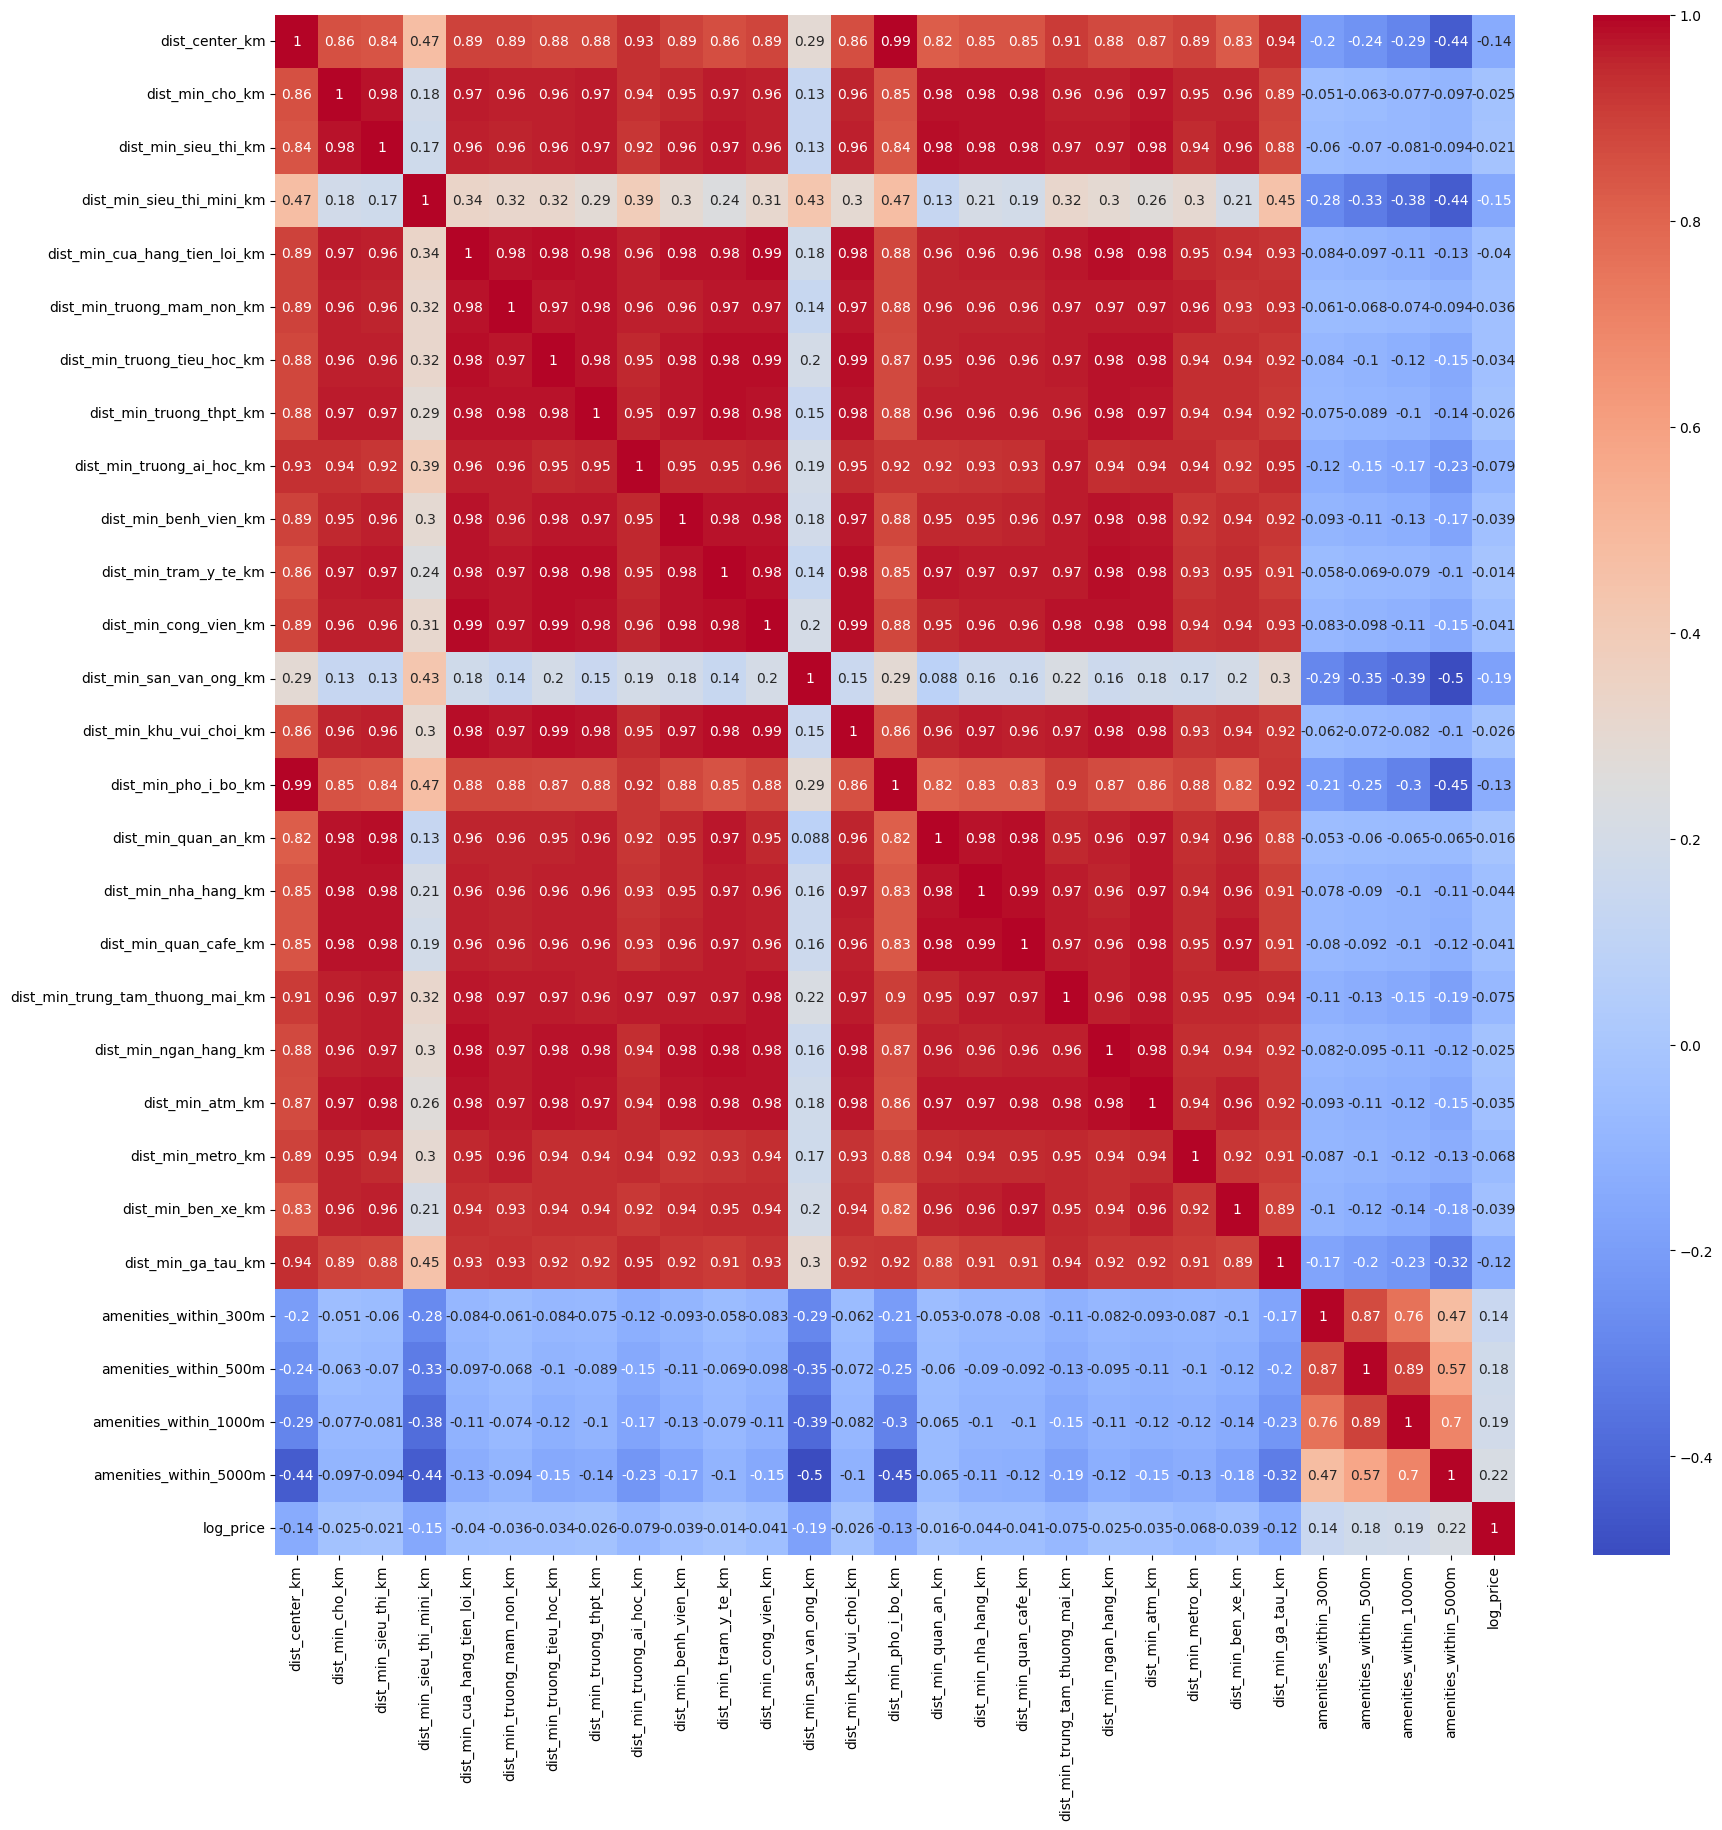

In [14]:
corr_matrix.style.background_gradient(cmap='coolwarm')

# Option 2: Seaborn Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Phân tích cho các đặc trưng mới tạo:

1. Các đặc trưng về khoảng cách như khoảng cách tới trung tâm thành phố và khoảng cách tới các đặc trưng.

Ta thấy log_price tỉ lệ nghịch với các khoảng cách, tức là khoảng cách tới trung tâm hay các tiện ích càng nhỏ thì giá càng cao. Rất phù hợp với đánh gia ban đầu về các đặc trưng này.

Đặc biệt các khoảng cách như: khoảng cách tới trung tâm thành phố (-0.14), khoảng cách tới siêu thị mini (-0.15), khoảng cách tới sân vận động (-0.19), khoảng cách tới phố đi bộ (-0.13), khoảng cách tới ga tàu (-0.12). Thể hiện những tiện ích này sẽ ảnh hưởng tới giá nhiều nhất.

2. Các đặc trưng về số lượng tiện ích trong 300m, 500m, 1000m, 5000m.

Ta thấy có một sự tương quan lớn, tỉ lệ thuận với giá, nghĩa là số lượng tiện ích trong bán kinh càng lớn thì giá càng cao.

Đặc biệt tương quan càng tăng từ bán kinh 300m tới 5000m, đáng chú ý là giữa 500m và 1000m không có quá nhiều chênh lệch (0.18 so với 0.19).

Từ đây ta đưa ra kết luận những đặc trưng về tiện ích này có thể thay thế cho các thông tin về toạ độ địa lý (longitude, latitude) để biểu diễn thêm các ý nghĩa về cơ sở hạ tầng ảnh hưởng lên giá bất động sản.

In [15]:
s_amenities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28690 entries, 0 to 28689
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   area_name                         28690 non-null  object 
 1   category_name                     28690 non-null  object 
 2   floornumber                       776 non-null    float64
 3   is_main_street                    20919 non-null  object 
 4   floors                            13078 non-null  float64
 5   length                            20254 non-null  float64
 6   living_size                       10527 non-null  float64
 7   width                             20830 non-null  float64
 8   apartment_type_name               28690 non-null  object 
 9   property_legal_document_status    28690 non-null  object 
 10  rooms_count                       28690 non-null  object 
 11  toilets_count                     28690 non-null  object 
 12  furn

In [16]:
import pandas as pd

unique_values = {
    col: s_amenities_df[col].dropna().unique().tolist()
    for col in s_amenities_df.select_dtypes(include='object').columns
}

In [17]:
import json
print(json.dumps(unique_values, indent=4, ensure_ascii=False))

{
    "area_name": [
        "Thành phố Thủ Đức",
        "Quận 7",
        "Quận Tân Phú",
        "Quận 11",
        "Huyện Củ Chi",
        "Quận 8",
        "Quận Bình Tân",
        "Quận 12",
        "Quận 5",
        "Huyện Bình Chánh",
        "Huyện Hóc Môn",
        "Quận Gò Vấp",
        "Quận Bình Thạnh",
        "Huyện Cần Giờ",
        "Quận Tân Bình",
        "Quận 10",
        "Huyện Nhà Bè",
        "Quận 1",
        "Quận Phú Nhuận",
        "Quận 6",
        "Quận 4",
        "Quận 3"
    ],
    "category_name": [
        "Căn hộ/Chung cư",
        "Đất",
        "Văn phòng, Mặt bằng kinh doanh",
        "Nhà ở"
    ],
    "is_main_street": [
        false,
        true
    ],
    "apartment_type_name": [
        "Chung cư",
        "Duplex",
        "Không có thông tin",
        "Căn hộ dịch vụ, mini",
        "Officetel",
        "Tập thể, cư xá",
        "Penthouse"
    ],
    "property_legal_document_status": [
        "Hợp đồng mua bán",
        "Sổ hồng riêng",


# Tạo các đặc trưng về tiện ích cho dữ liệu cho thuê (u)

In [18]:
TRANSFORM_DATA_DIR = "/content/drive/MyDrive/Chotot Project/TransformData"
RAW_DATA_DIR = "/content/drive/MyDrive/Chotot Project/RawData"

In [19]:
# Paths
U_LISTINGS_PATH = os.path.join(TRANSFORM_DATA_DIR, 'u_listing_cleaned.csv')
AMENITIES_PATH = os.path.join(RAW_DATA_DIR, 'hcm_amenities.csv')
U_OUTPUT_PATH = os.path.join(TRANSFORM_DATA_DIR, 'u_listing_with_features.csv')

In [20]:
main(U_LISTINGS_PATH, AMENITIES_PATH, U_OUTPUT_PATH)

Loading data...
Listings shape: (37882, 23)
Amenities shape: (2910, 6)
Cleaning listing data...
Listings shape after dropping missing lat/lng: (37871, 23)
Calculating distance to HCM Center...
Calculating distances to amenity types...
  Processing chợ...
  Processing siêu thị...
  Processing siêu thị mini...
  Processing cửa hàng tiện lợi...
  Processing trường mầm non...
  Processing trường tiểu học...
  Processing trường thpt...
  Processing trường đại học...
  Processing bệnh viện...
  Processing trạm y tế...
  Processing công viên...
  Processing sân vận động...
  Processing khu vui chơi...
  Processing phố đi bộ...
  Processing quán ăn...
  Processing nhà hàng...
  Processing quán cafe...
  Processing trung tâm thương mại...
  Processing ngân hàng...
  Processing atm...
  Processing metro...
  Processing bến xe...
  Processing ga tàu...
Calculating amenity counts within radii...
  Radius 300m...
  Radius 500m...
  Radius 1000m...
  Radius 5000m...
Saving to /content/drive/MyDrive/

In [22]:
u_amenities_df = pd.read_csv(U_OUTPUT_PATH)

In [23]:
u_amenities_df.head()

,area_name,category_name,floornumber,is_main_street,floors,length,living_size,width,apartment_type_name,deposit,...,dist_min_trung_tam_thuong_mai_km,dist_min_ngan_hang_km,dist_min_atm_km,dist_min_metro_km,dist_min_ben_xe_km,dist_min_ga_tau_km,amenities_within_300m,amenities_within_500m,amenities_within_1000m,amenities_within_5000m
0,Huyện Nhà Bè,Nhà ở,NaN,NaN,1.0,8.0,40.0,5.0,Không có thông tin,3000000.0,...,6.671439,3.366233,6.888279,4.685648,10.497642,12.167175,0,0,2,18
1,Quận 10,Nhà ở,NaN,True,3.0,20.0,80.0,4.0,Không có thông tin,0.0,...,0.979815,0.588950,0.176155,1.881565,0.456759,1.844218,3,13,67,1182
2,Huyện Nhà Bè,Đất,NaN,True,NaN,6.0,NaN,12.6,Không có thông tin,15000000.0,...,6.671439,3.366233,6.888279,4.685648,10.497642,12.167175,0,0,2,18
3,Quận Bình Thạnh,Phòng trọ,NaN,True,NaN,NaN,NaN,NaN,Không có thông tin,6500000.0,...,1.427462,0.621074,0.697035,3.080258,0.935884,1.585704,0,2,15,720
4,Thành phố Thủ Đức,Phòng trọ,NaN,True,NaN,NaN,NaN,NaN,Không có thông tin,3000000.0,...,0.271438,0.687673,0.220785,3.158888,0.922390,1.365012,7,8,15,363


In [24]:
u_amenities_df.columns

Index(['area_name', 'category_name', 'floornumber', 'is_main_street', 'floors',
       'length', 'living_size', 'width', 'apartment_type_name', 'deposit',
       'rooms_count', 'toilets_count', 'furnishing_rent_status',
       'balconydirection_name', 'direction_name', 'house_type_name',
       'commercial_type_name', 'land_type_name', 'log_price', 'log_size',
       'is_good_room', 'dist_center_km', 'dist_min_cho_km',
       'dist_min_sieu_thi_km', 'dist_min_sieu_thi_mini_km',
       'dist_min_cua_hang_tien_loi_km', 'dist_min_truong_mam_non_km',
       'dist_min_truong_tieu_hoc_km', 'dist_min_truong_thpt_km',
       'dist_min_truong_ai_hoc_km', 'dist_min_benh_vien_km',
       'dist_min_tram_y_te_km', 'dist_min_cong_vien_km',
       'dist_min_san_van_ong_km', 'dist_min_khu_vui_choi_km',
       'dist_min_pho_i_bo_km', 'dist_min_quan_an_km', 'dist_min_nha_hang_km',
       'dist_min_quan_cafe_km', 'dist_min_trung_tam_thuong_mai_km',
       'dist_min_ngan_hang_km', 'dist_min_atm_km', 'dist

In [25]:
amenities_features_columns = ['dist_center_km',
       'dist_min_cho_km', 'dist_min_sieu_thi_km', 'dist_min_sieu_thi_mini_km',
       'dist_min_cua_hang_tien_loi_km', 'dist_min_truong_mam_non_km',
       'dist_min_truong_tieu_hoc_km', 'dist_min_truong_thpt_km',
       'dist_min_truong_ai_hoc_km', 'dist_min_benh_vien_km',
       'dist_min_tram_y_te_km', 'dist_min_cong_vien_km',
       'dist_min_san_van_ong_km', 'dist_min_khu_vui_choi_km',
       'dist_min_pho_i_bo_km', 'dist_min_quan_an_km', 'dist_min_nha_hang_km',
       'dist_min_quan_cafe_km', 'dist_min_trung_tam_thuong_mai_km',
       'dist_min_ngan_hang_km', 'dist_min_atm_km', 'dist_min_metro_km',
       'dist_min_ben_xe_km', 'dist_min_ga_tau_km', 'amenities_within_300m',
       'amenities_within_500m', 'amenities_within_1000m',
       'amenities_within_5000m']

In [26]:
price_amenities_features_df = u_amenities_df[amenities_features_columns + ['log_price']]

In [27]:
price_amenities_features_df

,dist_center_km,dist_min_cho_km,dist_min_sieu_thi_km,dist_min_sieu_thi_mini_km,dist_min_cua_hang_tien_loi_km,dist_min_truong_mam_non_km,dist_min_truong_tieu_hoc_km,dist_min_truong_thpt_km,dist_min_truong_ai_hoc_km,dist_min_benh_vien_km,...,dist_min_ngan_hang_km,dist_min_atm_km,dist_min_metro_km,dist_min_ben_xe_km,dist_min_ga_tau_km,amenities_within_300m,amenities_within_500m,amenities_within_1000m,amenities_within_5000m,log_price
0,12.376233,5.510077,1.417182,3.342835,3.766971,0.929071,6.172413,1.244185,3.851987,4.705804,...,3.366233,6.888279,4.685648,10.497642,12.167175,0,0,2,18,6.477121
1,3.412426,0.225915,0.485745,0.452625,0.620651,0.529599,0.555649,0.571690,0.391170,0.332936,...,0.588950,0.176155,1.881565,0.456759,1.844218,3,13,67,1182,7.602060
2,12.376233,5.510077,1.417182,3.342835,3.766971,0.929071,6.172413,1.244185,3.851987,4.705804,...,3.366233,6.888279,4.685648,10.497642,12.167175,0,0,2,18,6.698970
3,4.723946,0.819319,0.790676,1.238364,0.700167,0.823905,1.025798,0.416533,1.011084,1.584821,...,0.621074,0.697035,3.080258,0.935884,1.585704,0,2,15,720,6.812913
4,6.016306,1.943517,0.201386,3.051935,1.086688,1.021877,2.155786,1.777560,2.027847,1.854068,...,0.687673,0.220785,3.158888,0.922390,1.365012,7,8,15,363,6.477121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37866,2.913725,0.498642,0.236532,0.886782,0.418918,0.421624,0.428299,1.053721,0.541490,0.129137,...,0.507895,0.936954,1.036145,1.993142,1.008703,3,9,49,1199,6.477121
37867,8.548629,2.200031,2.126299,2.070504,0.457918,1.159396,2.742731,3.233383,3.408604,1.335256,...,1.099895,0.460235,5.137007,1.594779,2.864039,0,4,7,236,6.525045
37868,4.723946,0.819319,0.790676,1.238364,0.700167,0.823905,1.025798,0.416533,1.011084,1.584821,...,0.621074,0.697035,3.080258,0.935884,1.585704,0,2,15,720,6.740363
37869,8.852758,1.364627,0.990917,1.031821,0.373384,0.298453,1.285287,0.251720,0.387726,3.081201,...,0.243194,0.891697,2.067203,1.016253,1.257066,5,12,33,573,6.447158


In [28]:
corr_matrix = price_amenities_features_df.corr()

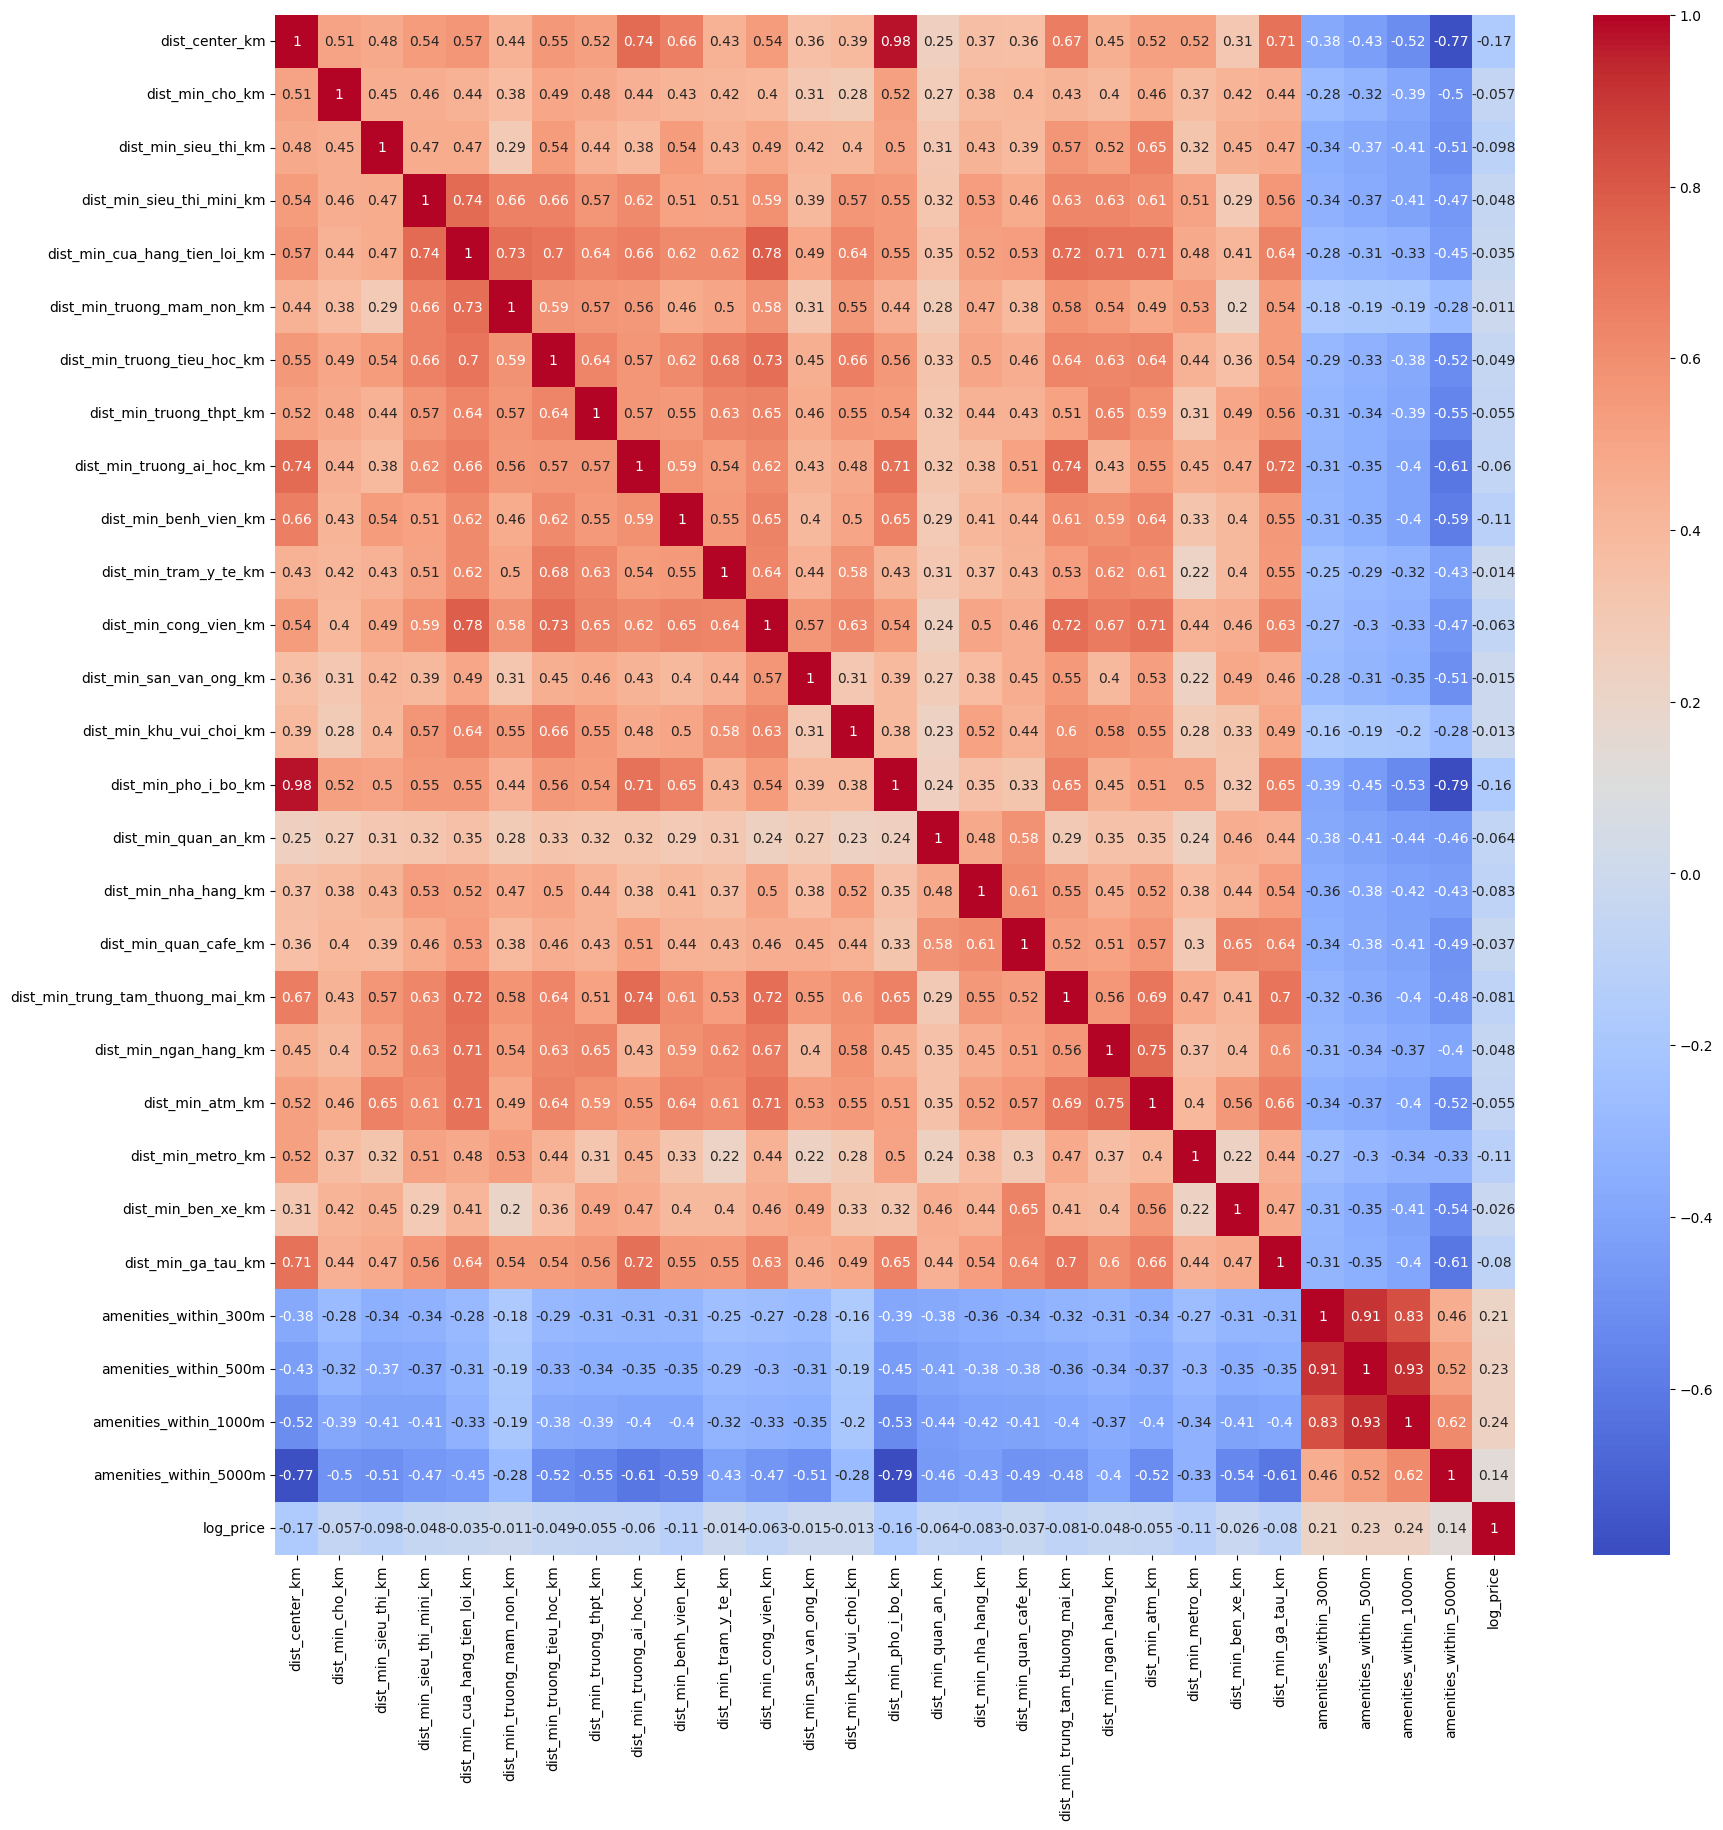

In [29]:
corr_matrix.style.background_gradient(cmap='coolwarm')

# Option 2: Seaborn Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

Phân tích cho các đặc trưng mới tạo:

1. Các đặc trưng về khoảng cách như khoảng cách tới trung tâm thành phố và khoảng cách tới các đặc trưng.

Ta thấy log_price tỉ lệ nghịch với các khoảng cách, tức là khoảng cách tới trung tâm hay các tiện ích càng nhỏ thì giá càng cao. Rất phù hợp với đánh gia ban đầu về các đặc trưng này.

Đặc biệt các khoảng cách như: khoảng cách tới trung tâm thành phố (-0.14), khoảng cách tới siêu thị mini (-0.15), khoảng cách tới sân vận động (-0.19), khoảng cách tới phố đi bộ (-0.13), khoảng cách tới ga tàu (-0.12). Thể hiện những tiện ích này sẽ ảnh hưởng tới giá nhiều nhất.

2. Các đặc trưng về số lượng tiện ích trong 300m, 500m, 1000m, 5000m.

Ta thấy có một sự tương quan lớn, tỉ lệ thuận với giá, nghĩa là số lượng tiện ích trong bán kinh càng lớn thì giá càng cao.

Đặc biệt tương quan càng tăng từ bán kinh 300m tới 5000m, đáng chú ý là giữa 500m và 1000m không có quá nhiều chênh lệch (0.18 so với 0.19).

Từ đây ta đưa ra kết luận những đặc trưng về tiện ích này có thể thay thế cho các thông tin về toạ độ địa lý (longitude, latitude) để biểu diễn thêm các ý nghĩa về cơ sở hạ tầng ảnh hưởng lên giá bất động sản.

In [30]:
u_amenities_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37871 entries, 0 to 37870
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   area_name                         37870 non-null  object 
 1   category_name                     37871 non-null  object 
 2   floornumber                       1523 non-null   float64
 3   is_main_street                    27275 non-null  object 
 4   floors                            4525 non-null   float64
 5   length                            7326 non-null   float64
 6   living_size                       4834 non-null   float64
 7   width                             7368 non-null   float64
 8   apartment_type_name               37871 non-null  object 
 9   deposit                           37871 non-null  float64
 10  rooms_count                       37871 non-null  object 
 11  toilets_count                     37871 non-null  object 
 12  furn

In [31]:
import pandas as pd

unique_values = {
    col: u_amenities_df[col].dropna().unique().tolist()
    for col in u_amenities_df.select_dtypes(include='object').columns
}

In [32]:
import json
print(json.dumps(unique_values, indent=4, ensure_ascii=False))

{
    "area_name": [
        "Huyện Nhà Bè",
        "Quận 10",
        "Quận Bình Thạnh",
        "Thành phố Thủ Đức",
        "Quận 7",
        "Quận 8",
        "Quận Gò Vấp",
        "Quận 12",
        "Quận 6",
        "Huyện Bình Chánh",
        "Quận Tân Bình",
        "Quận 11",
        "Quận Bình Tân",
        "Quận 5",
        "Quận Tân Phú",
        "Quận 4",
        "Quận Phú Nhuận",
        "Huyện Hóc Môn",
        "Quận 1",
        "Quận 3",
        "Huyện Củ Chi",
        "Huyện Cần Giờ"
    ],
    "category_name": [
        "Nhà ở",
        "Đất",
        "Phòng trọ",
        "Căn hộ/Chung cư",
        "Văn phòng, Mặt bằng kinh doanh"
    ],
    "is_main_street": [
        true,
        false
    ],
    "apartment_type_name": [
        "Không có thông tin",
        "Chung cư",
        "Căn hộ dịch vụ, mini",
        "Officetel",
        "Duplex",
        "Tập thể, cư xá",
        "Penthouse"
    ],
    "rooms_count": [
        "1",
        "6",
        "Không có thông t